## Homework 5
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [18]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import QFTGate
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-03-07 15:56:29,448: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-07 15:56:30,330: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-07 15:56:32,523: Using instance: open-instance, plan: open


## Problem 1

In [4]:
def qft(qc):
    n = 5
    for i in range(n):
        qc.h(i)
        for j in range(i+1, n):
            qc.cp(np.pi/(2**(j-i)), j, i)

    for i in range(n//2):
        qc.swap(i, n-i-1)

    return qc

## (a)

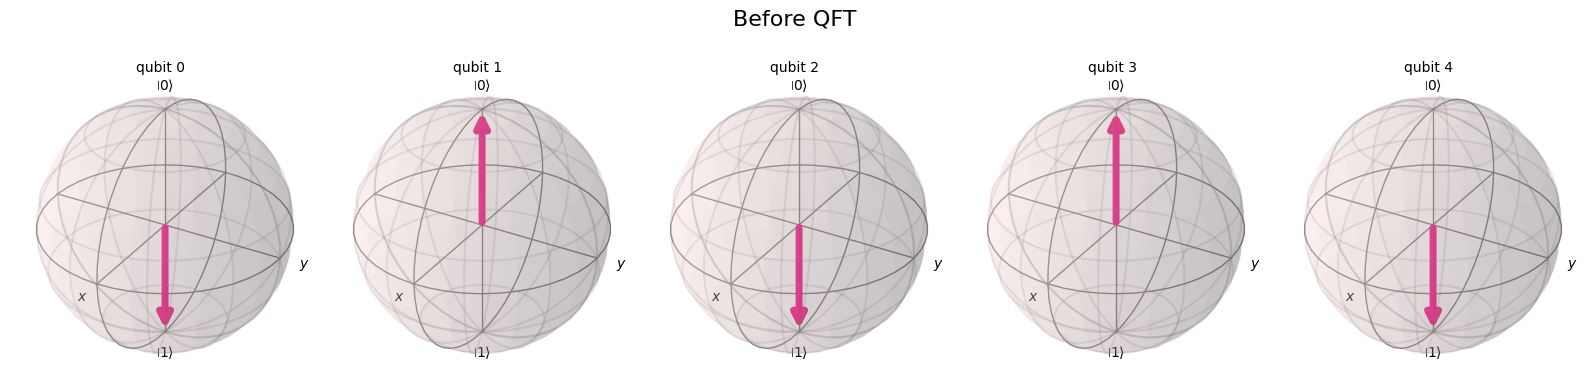

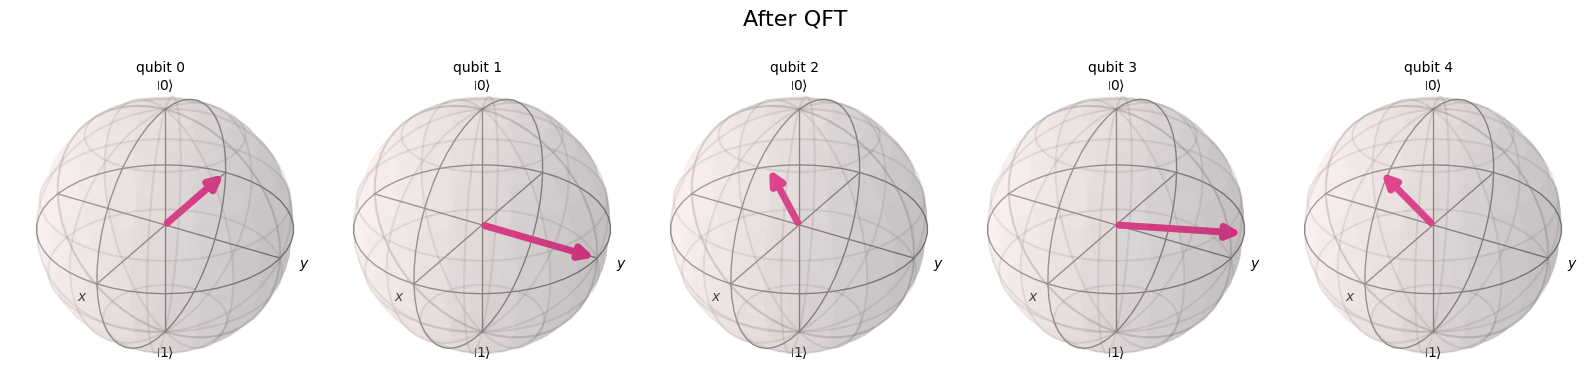

In [13]:
qc = QuantumCircuit(5)

# k = 10101
qc.x(0)
qc.x(2)
qc.x(4)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state, title="Before QFT");

qc = qft(qc)


state = Statevector.from_instruction(qc)
plot_bloch_multivector(state,  title="After QFT");

## (b)

In [11]:
def iqft(qc):
    n = 5

    for i in range(n//2):
        qc.swap(i, n-i-1)
    
    for i in reversed(range(n)):
        for j in reversed(range(i+1, n)):
            qc.cp(-np.pi/(2**(j-i)), j, i)
        qc.h(i)

    return qc

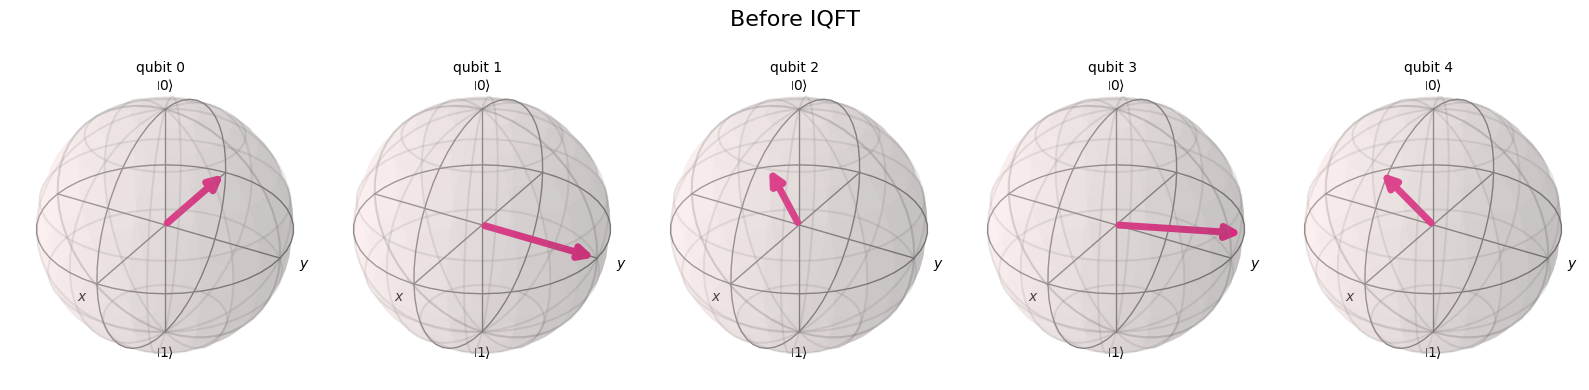

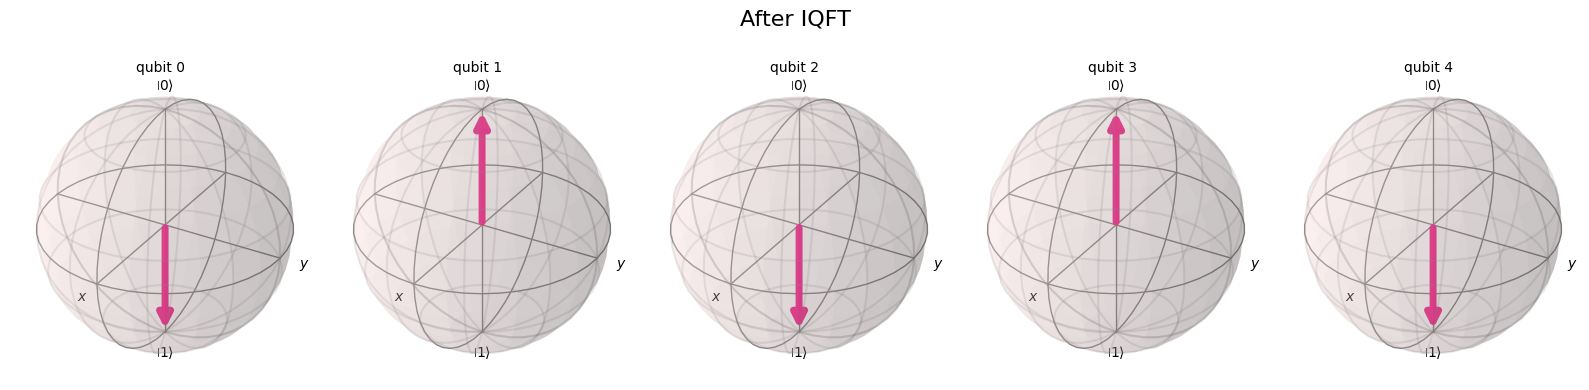

In [15]:
qc = QuantumCircuit(5)

# k = 10101
qc.x(0)
qc.x(2)
qc.x(4)
qc = qft(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state, title="Before IQFT");

qc = iqft(qc)


state = Statevector.from_instruction(qc)
plot_bloch_multivector(state,  title="After IQFT");

## (c)

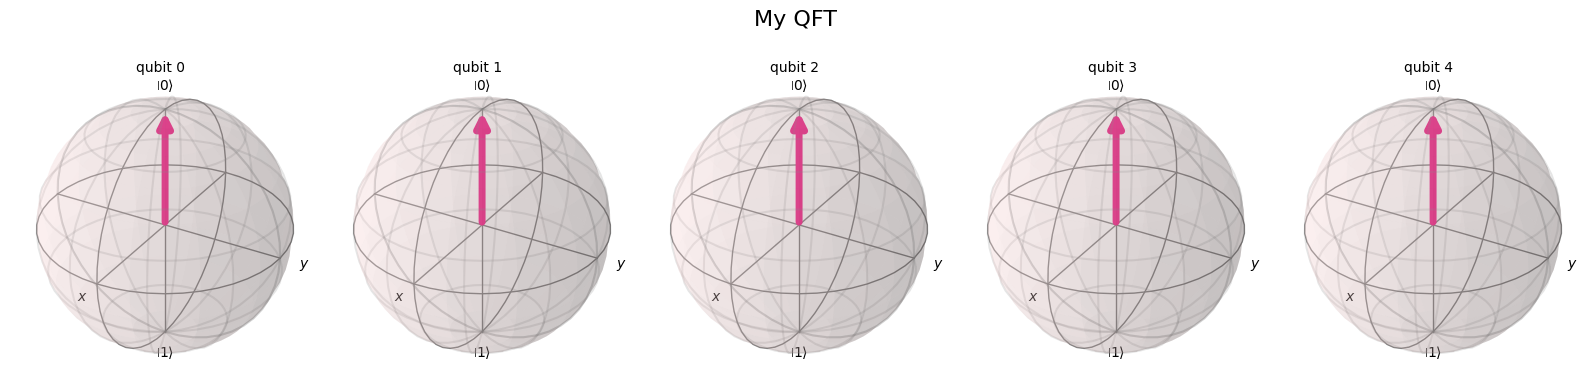

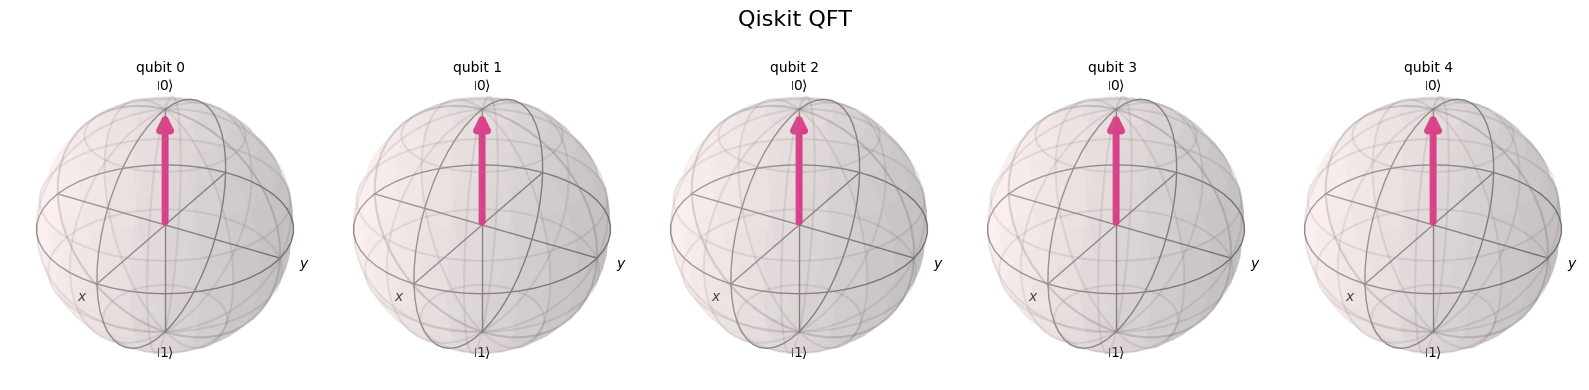

In [26]:
qc = QuantumCircuit(5)
for i in range(5):
    qc.h(i)
qc = qft(qc)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state, title="My QFT");

qc = QuantumCircuit(5)
for i in range(5):
    qc.h(i)
qft_qc = QFTGate(5)
qc.compose(qft_qc, inplace=True)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state, title="Qiskit QFT");

## Problem 2

In [46]:
def U(qc, p):
    for i in range(4):
        qc.p( 2*np.pi*p/(2**(4-i)), 3+i)

def cU(qc, control, p):
    for i in range(4):
        qc.cp( 2*np.pi*p/(2**(4-i)), control, 3+i)

# g(x0,x1,x2) = 3x0x1 - 2x1x2 - x0x2 + 1 
def g(x0, x1, x2):
    qc = QuantumCircuit(8, 4)
    creg = [3,4,5,6]

    # prep init state
    if x0 == 1:
        qc.x(0)
    if x1 == 1:
        qc.x(1)
    if x2 == 1:
        qc.x(2)

    qft_qc = QFTGate(4)
    qc.compose(qft_qc, creg, inplace=True)

    # +1
    U(qc, 1)

    # +3 x0x1
    qc.ccx(0,1,7)  # temporary AND ancilla q8
    cU(qc, 7, 3)
    qc.ccx(0,1,7)

    # -2 x1x2
    qc.ccx(1,2,7)
    cU(qc, 7, -2)
    qc.ccx(1,2,7)

    # -1 x0x2
    qc.ccx(0,2,7)
    cU(qc, 7, -1)
    qc.ccx(0,2,7)

    # back to binary
    iqft_qc = QFTGate(4).inverse()
    qc.compose(iqft_qc, creg, inplace=True)

    qc.measure(creg, range(4))

    return qc

Counts: {'0100': 1024}
Counts: {'0010': 8, '1111': 3, '1101': 2, '0100': 44, '0011': 7, '1000': 11, '1100': 14, '1010': 6, '0000': 14, '1001': 3, '0001': 6, '1110': 1, '1011': 2, '0101': 3, '0110': 2, '0111': 2}


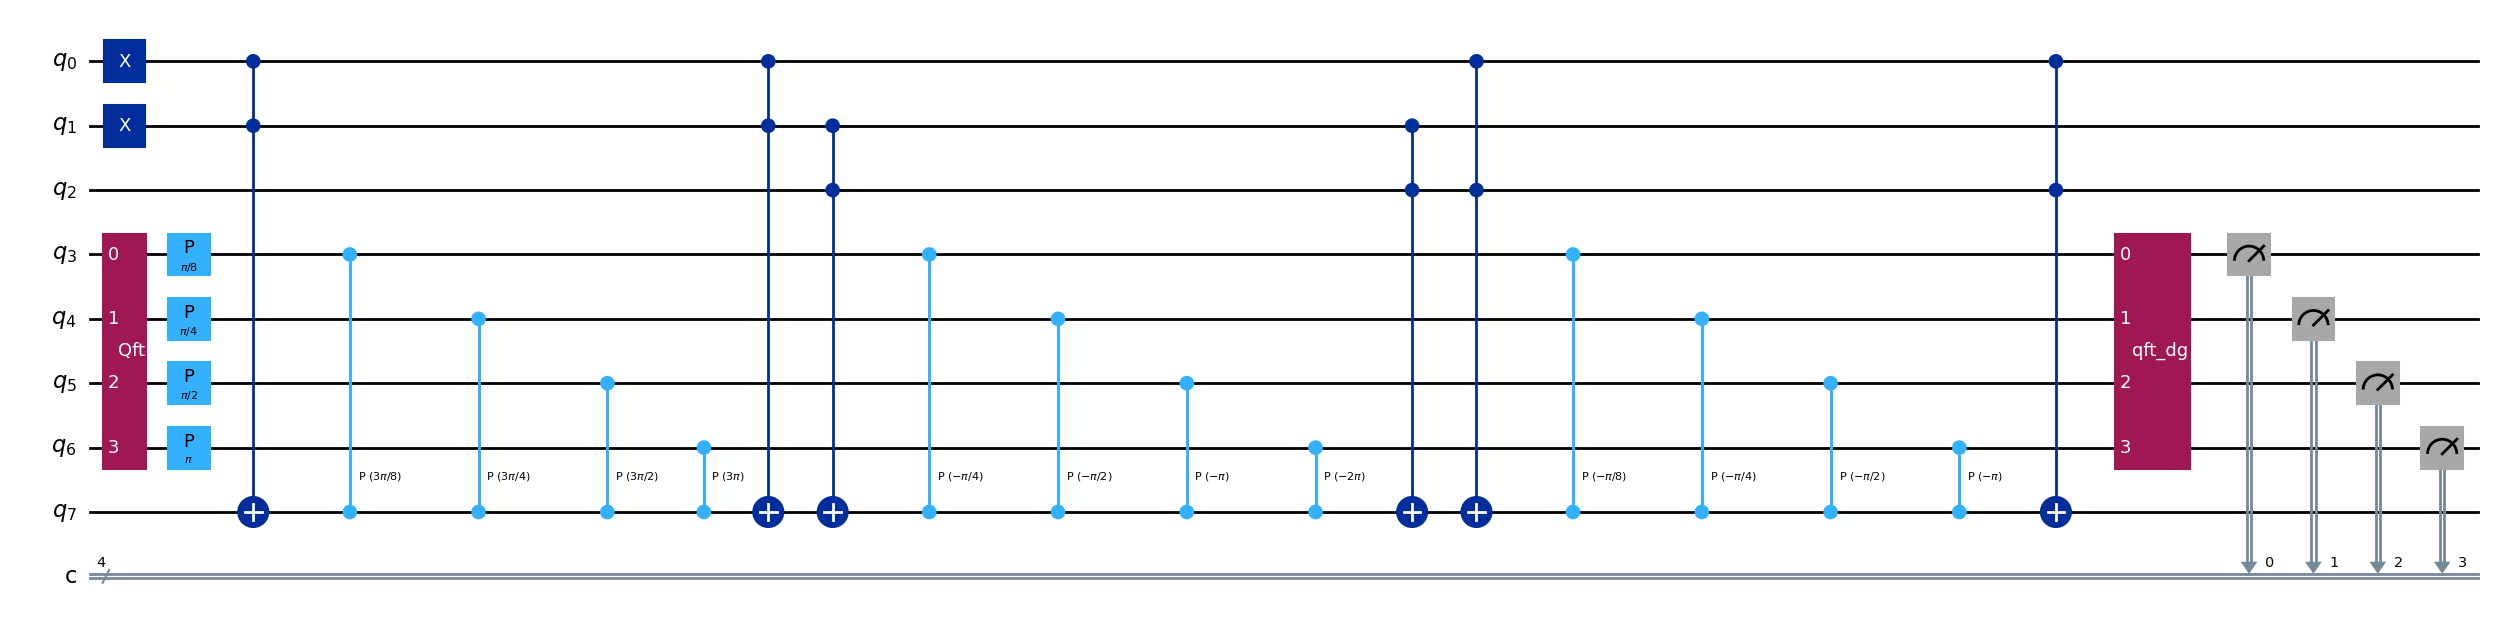

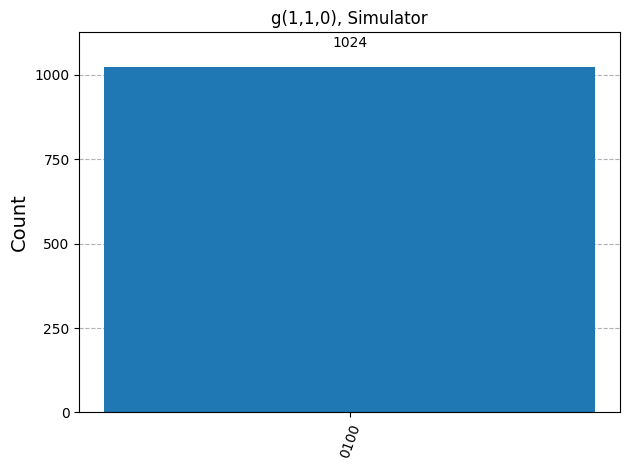

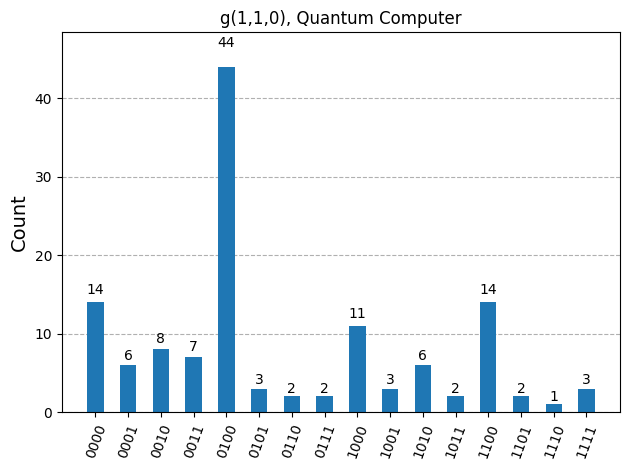

In [ ]:
# g(1,1,0) = 3*1*1 - 2*1*0 - 1*1*0 + 1 = 4 (0100 in 4-bitbinary)
qc = g(1,1,0)
qc.draw("mpl", fold=-1);

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="g(1,1,0), Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="g(1,1,0), Quantum Computer");

Counts: {'1111': 1024}
Counts: {'1011': 9, '0111': 20, '1101': 16, '1111': 38, '1001': 6, '0100': 2, '0101': 5, '1100': 2, '0110': 6, '1000': 3, '0001': 10, '0011': 4, '1010': 2, '1110': 4, '0000': 1}


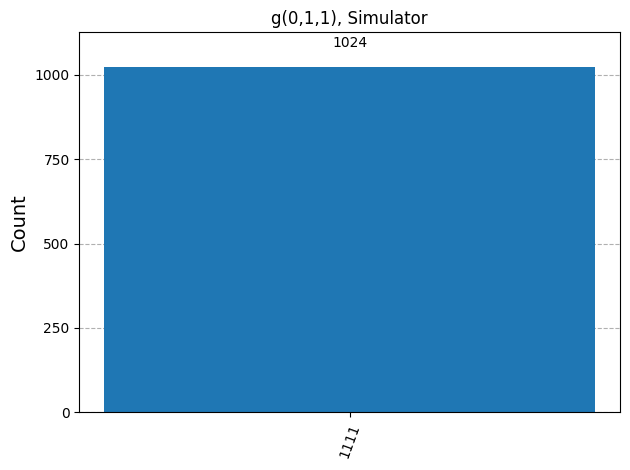

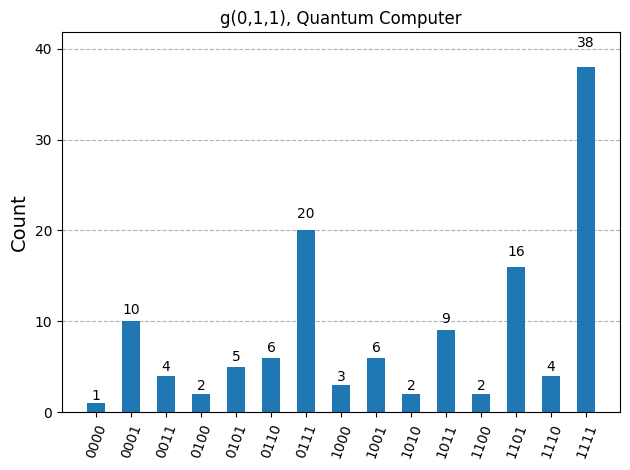

In [ ]:
# g(0,1,1) = 3*0*1 - 2*1*1 - 1*0*1 + 1 = -1 (1111 in 4-bit binary)
qc = g(0,1,1)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="g(0,1,1), Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="g(0,1,1), Quantum Computer");

